In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
df=pd.read_csv("Diabetes_Prediction_Dataset.csv")
df.head()

,Patient_ID,Age,Gender,BMI,Glucose,Blood_Pressure,Cholesterol,Insulin,HbA1c,Smoking_Status,Physical_Activity,Family_History,Diabetes
0,1,58,Male,17.6,140.0,121,177,86,9.7,Current,High,Yes,Yes
1,2,56,Male,31.0,209.0,143,176,244,8.6,Never,Low,No,Yes
2,3,23,Female,19.4,158.0,167,187,37,9.6,Current,Low,No,No
3,4,41,Male,34.6,81.0,174,178,163,11.4,Never,Low,No,No
4,5,31,Female,34.5,88.0,167,282,102,8.2,Never,Low,No,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         5000 non-null   int64  
 1   Age                5000 non-null   int64  
 2   Gender             5000 non-null   object 
 3   BMI                4893 non-null   float64
 4   Glucose            4930 non-null   float64
 5   Blood_Pressure     5000 non-null   int64  
 6   Cholesterol        5000 non-null   int64  
 7   Insulin            5000 non-null   int64  
 8   HbA1c              5000 non-null   float64
 9   Smoking_Status     5000 non-null   object 
 10  Physical_Activity  5000 non-null   object 
 11  Family_History     5000 non-null   object 
 12  Diabetes           5000 non-null   object 
dtypes: float64(3), int64(5), object(5)
memory usage: 507.9+ KB


In [5]:
df.shape

(5000, 13)

In [6]:
df.describe()

,Patient_ID,Age,BMI,Glucose,Blood_Pressure,Cholesterol,Insulin,HbA1c
count,5000.000000,5000.000000,4893.000000,4930.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,48.986400,29.407398,144.456795,143.139200,221.426800,157.746200,7.988300
std,1443.520003,18.173813,7.254359,43.887777,87.414816,57.436379,82.357275,2.017408
min,1.000000,18.000000,17.000000,70.000000,90.000000,120.000000,15.000000,4.500000
25%,1250.750000,33.000000,23.100000,106.000000,112.000000,172.000000,86.000000,6.200000
50%,2500.500000,49.000000,29.400000,144.000000,136.000000,222.000000,158.000000,7.900000
75%,3750.250000,65.000000,35.800000,182.000000,158.000000,271.000000,229.000000,9.800000
max,5000.000000,80.000000,42.000000,220.000000,999.000000,320.000000,300.000000,11.500000


In [7]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Glucose', 'Blood_Pressure',
       'Cholesterol', 'Insulin', 'HbA1c', 'Smoking_Status',
       'Physical_Activity', 'Family_History', 'Diabetes'],
      dtype='object')

In [8]:
df.dtypes

Patient_ID             int64
Age                    int64
Gender                object
BMI                  float64
Glucose              float64
Blood_Pressure         int64
Cholesterol            int64
Insulin                int64
HbA1c                float64
Smoking_Status        object
Physical_Activity     object
Family_History        object
Diabetes              object
dtype: object

In [9]:
df.isnull().sum()

Patient_ID             0
Age                    0
Gender                 0
BMI                  107
Glucose               70
Blood_Pressure         0
Cholesterol            0
Insulin                0
HbA1c                  0
Smoking_Status         0
Physical_Activity      0
Family_History         0
Diabetes               0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

Patient_ID           0.00
Age                  0.00
Gender               0.00
BMI                  2.14
Glucose              1.40
Blood_Pressure       0.00
Cholesterol          0.00
Insulin              0.00
HbA1c                0.00
Smoking_Status       0.00
Physical_Activity    0.00
Family_History       0.00
Diabetes             0.00
dtype: float64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop("Patient_ID",axis=1,inplace=True)

In [13]:
df.head()

,Age,Gender,BMI,Glucose,Blood_Pressure,Cholesterol,Insulin,HbA1c,Smoking_Status,Physical_Activity,Family_History,Diabetes
0,58,Male,17.6,140.0,121,177,86,9.7,Current,High,Yes,Yes
1,56,Male,31.0,209.0,143,176,244,8.6,Never,Low,No,Yes
2,23,Female,19.4,158.0,167,187,37,9.6,Current,Low,No,No
3,41,Male,34.6,81.0,174,178,163,11.4,Never,Low,No,No
4,31,Female,34.5,88.0,167,282,102,8.2,Never,Low,No,No


In [14]:
df['BMI'].fillna(df['BMI'].median(), inplace=True)
df['Glucose'].fillna(df['Glucose'].mean(), inplace=True)

In [15]:
df.loc[df['Blood_Pressure'] > 250, 'Blood_Pressure'] = df['Blood_Pressure'].median()

In [16]:
df = df[df['Gender'] != 'Unknown']

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
(df.isnull().sum()/len(df))*100

Age                  0.0
Gender               0.0
BMI                  0.0
Glucose              0.0
Blood_Pressure       0.0
Cholesterol          0.0
Insulin              0.0
HbA1c                0.0
Smoking_Status       0.0
Physical_Activity    0.0
Family_History       0.0
Diabetes             0.0
dtype: float64

In [19]:
# Check unique values for each categorical column
print("Gender:", df['Gender'].unique())
print("Smoking_Status:", df['Smoking_Status'].unique())
print("Physical_Activity:", df['Physical_Activity'].unique())
print("Family_History:", df['Family_History'].unique())
print("Diabetes:", df['Diabetes'].unique())

# If you want counts for each category
print(df['Gender'].value_counts())
print(df['Smoking_Status'].value_counts())
print(df['Physical_Activity'].value_counts())
print(df['Family_History'].value_counts())
print(df['Diabetes'].value_counts())


Gender: ['Male' 'Female']
Smoking_Status: ['Current' 'Never' 'Former']
Physical_Activity: ['High' 'Low' 'Moderate']
Family_History: ['Yes' 'No']
Diabetes: ['Yes' 'No']
Gender
Female    2525
Male      2429
Name: count, dtype: int64
Smoking_Status
Former     1695
Never      1634
Current    1625
Name: count, dtype: int64
Physical_Activity
Moderate    1714
Low         1657
High        1583
Name: count, dtype: int64
Family_History
No     2481
Yes    2473
Name: count, dtype: int64
Diabetes
Yes    2961
No     1993
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import LabelEncoder
binary_cols = ['Gender', 'Family_History', 'Diabetes']
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
df = pd.get_dummies(df, columns=['Smoking_Status', 'Physical_Activity'], drop_first=True)


In [21]:
df.head()

,Age,Gender,BMI,Glucose,Blood_Pressure,Cholesterol,Insulin,HbA1c,Family_History,Diabetes,Smoking_Status_Former,Smoking_Status_Never,Physical_Activity_Low,Physical_Activity_Moderate
0,58,1,17.6,140.0,121,177,86,9.7,1,1,False,False,False,False
1,56,1,31.0,209.0,143,176,244,8.6,0,1,False,True,True,False
2,23,0,19.4,158.0,167,187,37,9.6,0,0,False,False,True,False
3,41,1,34.6,81.0,174,178,163,11.4,0,0,False,True,True,False
4,31,0,34.5,88.0,167,282,102,8.2,0,0,False,True,True,False


In [22]:

X = df.drop('Diabetes', axis=1)


y = df['Diabetes']




In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [24]:
from sklearn.tree import DecisionTreeClassifier


dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)


dt_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))


print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.992936427850656
Precision: 0.9982964224872232
Recall: 0.9898648648648649
F1-score: 0.9940627650551315
Confusion Matrix:
 [[398   1]
 [  6 586]]


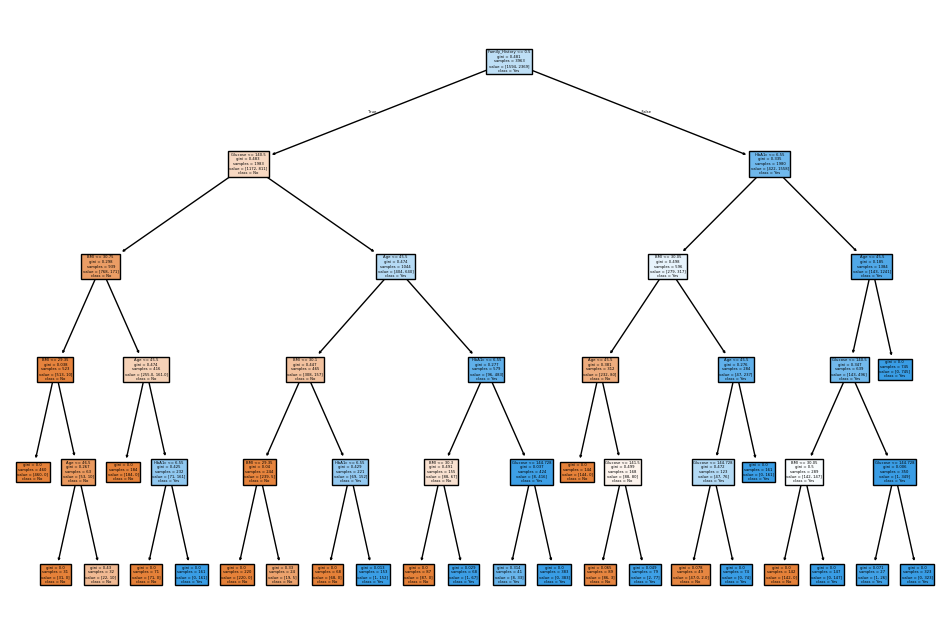

In [27]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
tree.plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['No','Yes'])
plt.show()


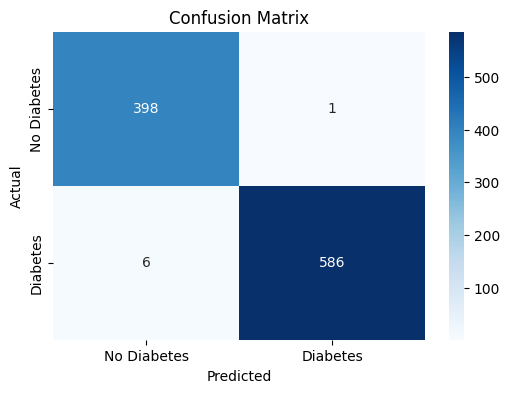

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [33]:
new_patient = pd.DataFrame([{
    "Age": 45,
    "Gender": 1,
    "BMI": 28.5,
    "Glucose": 150,
    "Blood_Pressure": 130,
    "Cholesterol": 200,
    "Insulin": 160,
    "HbA1c": 8.0,
    "Family_History": 1,
    "Smoking_Status_Former": 0,
    "Smoking_Status_Never": 0,
    "Physical_Activity_Low": 0,
    "Physical_Activity_Moderate": 1
}], columns=X.columns)

prediction = dt_model.predict(new_patient)
print("Predicted Diabetes:", "Yes" if prediction[0] == 1 else "No")


Predicted Diabetes: Yes


In [32]:
print(X.columns)


Index(['Age', 'Gender', 'BMI', 'Glucose', 'Blood_Pressure', 'Cholesterol',
       'Insulin', 'HbA1c', 'Family_History', 'Smoking_Status_Former',
       'Smoking_Status_Never', 'Physical_Activity_Low',
       'Physical_Activity_Moderate'],
      dtype='object')


In [34]:
import json

def tree_to_json(tree_model, feature_names, class_names):
    """Convert a fitted sklearn DecisionTreeClassifier into a plain nested-dict tree."""
    tree_ = tree_model.tree_

    def recurse(node_id):
        # Leaf node
        if tree_.children_left[node_id] == tree_.children_right[node_id]:
            class_idx = int(tree_.value[node_id].argmax())
            return {
                "leaf": True,
                "prediction": class_names[class_idx],
                "prediction_encoded": class_idx,
            }
        return {
            "leaf": False,
            "feature": feature_names[tree_.feature[node_id]],
            "threshold": float(tree_.threshold[node_id]),
            "left": recurse(tree_.children_left[node_id]),   # goes here if feature <= threshold
            "right": recurse(tree_.children_right[node_id]),  # goes here if feature > threshold
        }

    return recurse(0)

model_tree_json = tree_to_json(dt_model, list(X.columns), ["No", "Yes"])

with open("diabetes_model.json", "w") as f:
    json.dump(model_tree_json, f, indent=2)

print("Model saved as diabetes_model.json")


Model saved as diabetes_model.json


In [35]:
new_patient = pd.DataFrame([{
    "Age": 45,
    "Gender": 1,
    "BMI": 28.5,
    "Glucose": 150,
    "Blood_Pressure": 130,
    "Cholesterol": 200,
    "Insulin": 160,
    "HbA1c": 8.0,
    "Family_History": 1,
    "Smoking_Status_Former": 0,
    "Smoking_Status_Never": 0,
    "Physical_Activity_Low": 0,
    "Physical_Activity_Moderate": 1
}], columns=X.columns)

prediction = dt_model.predict(new_patient)
print("Predicted Diabetes:", "Yes" if prediction[0] == 1 else "No")


Predicted Diabetes: Yes
